# Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def bar_plot(data: pd.DataFrame, Title: str):
    data = data.copy()
    def extract_mean(value):
        return float(value.split('$\\pm$')[0])
    for column in data.columns:
        data[column] = data[column].apply(extract_mean)

    plt.figure(figsize=(16, 8))
    plt.xticks(rotation=90)
    bar_width = 0.12
    r = np.arange(len(data))
    for i, metric in enumerate(data.columns):
        plt.bar(r + i * bar_width, data[metric], width=bar_width, label=metric)
    plt.xlabel('Methods', fontweight='bold')
    plt.xticks(r + bar_width * (len(data.columns) - 1) / 2, data.index)
    plt.ylabel('Scores')
    plt.title(Title)
    plt.ylim(0, 100)
    plt.legend(title='Metrics', loc='center right')
    plt.tight_layout()
    plt.show()

## Citeseer

In [3]:
data0 = pd.read_csv('./Citeseer_res.csv', sep=';').T
data0.columns = data0.loc['metrics']
data0.drop(index='metrics', inplace=True)
data0.index = data0.index.str.replace('Citeseer ', '', regex=False)
print('Citeseer')
print(data0.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
data0

Citeseer
\begin{tabular}{lllll}
\toprule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
69.45$\pm$4.93 & 78.29$\pm$3.76 & 87.3$\pm$1.82 & 92.58$\pm$0.97 & 96.94$\pm$0.38 \\
70.07$\pm$4.62 & 78.02$\pm$2.69 & 86.21$\pm$1.05 & 91.67$\pm$0.71 & 96.93$\pm$0.35 \\
59.05$\pm$2.76 & 66.42$\pm$1.75 & 75.03$\pm$1.86 & 82.24$\pm$1.89 & 92.21$\pm$0.91 \\
59.0$\pm$3.93 & 66.45$\pm$2.23 & 74.02$\pm$1.53 & 80.89$\pm$0.93 & 92.32$\pm$0.52 \\
56.21$\pm$6.0 & 64.51$\pm$5.01 & 77.44$\pm$3.17 & 84.22$\pm$3.55 & 93.1$\pm$1.29 \\
53.75$\pm$8.25 & 62.29$\pm$5.22 & 75.25$\pm$4.27 & 82.89$\pm$3.76 & 92.91$\pm$1.2 \\
58.54$\pm$3.07 & 65.35$\pm$2.64 & 75.14$\pm$2.17 & 82.05$\pm$1.59 & 92.04$\pm$0.69 \\
57.71$\pm$2.88 & 64.69$\pm$2.21 & 73.73$\pm$1.37 & 80.55$\pm$1.2 & 91.87$\pm$0.63 \\
58.82$\pm$2.42 & 66.64$\pm$2.01 & 74.62$\pm$1.94 & 81.32$\pm$1.14 & 91.91$\pm$0.61 \\
59.32$\pm$2.39 & 64.84$\pm$1.98 & 72.66$\pm$1.27 & 79.88$\pm$1.32 & 91.92$\pm$0.71 \\
70.65$\pm$2.74 & 75.03$\pm$1.85 & 80.44$\pm$1

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,69.45$\pm$4.93,78.29$\pm$3.76,87.3$\pm$1.82,92.58$\pm$0.97,96.94$\pm$0.38
GCN+MLP,70.07$\pm$4.62,78.02$\pm$2.69,86.21$\pm$1.05,91.67$\pm$0.71,96.93$\pm$0.35
GRACE+NCN,59.05$\pm$2.76,66.42$\pm$1.75,75.03$\pm$1.86,82.24$\pm$1.89,92.21$\pm$0.91
GRACE+MLP,59.0$\pm$3.93,66.45$\pm$2.23,74.02$\pm$1.53,80.89$\pm$0.93,92.32$\pm$0.52
GCA_deg+NCN,56.21$\pm$6.0,64.51$\pm$5.01,77.44$\pm$3.17,84.22$\pm$3.55,93.1$\pm$1.29
GCA_deg+MLP,53.75$\pm$8.25,62.29$\pm$5.22,75.25$\pm$4.27,82.89$\pm$3.76,92.91$\pm$1.2
GCA_pr+NCN,58.54$\pm$3.07,65.35$\pm$2.64,75.14$\pm$2.17,82.05$\pm$1.59,92.04$\pm$0.69
GCA_pr+MLP,57.71$\pm$2.88,64.69$\pm$2.21,73.73$\pm$1.37,80.55$\pm$1.2,91.87$\pm$0.63
GCA_evc+NCN,58.82$\pm$2.42,66.64$\pm$2.01,74.62$\pm$1.94,81.32$\pm$1.14,91.91$\pm$0.61
GCA_evc+MLP,59.32$\pm$2.39,64.84$\pm$1.98,72.66$\pm$1.27,79.88$\pm$1.32,91.92$\pm$0.71


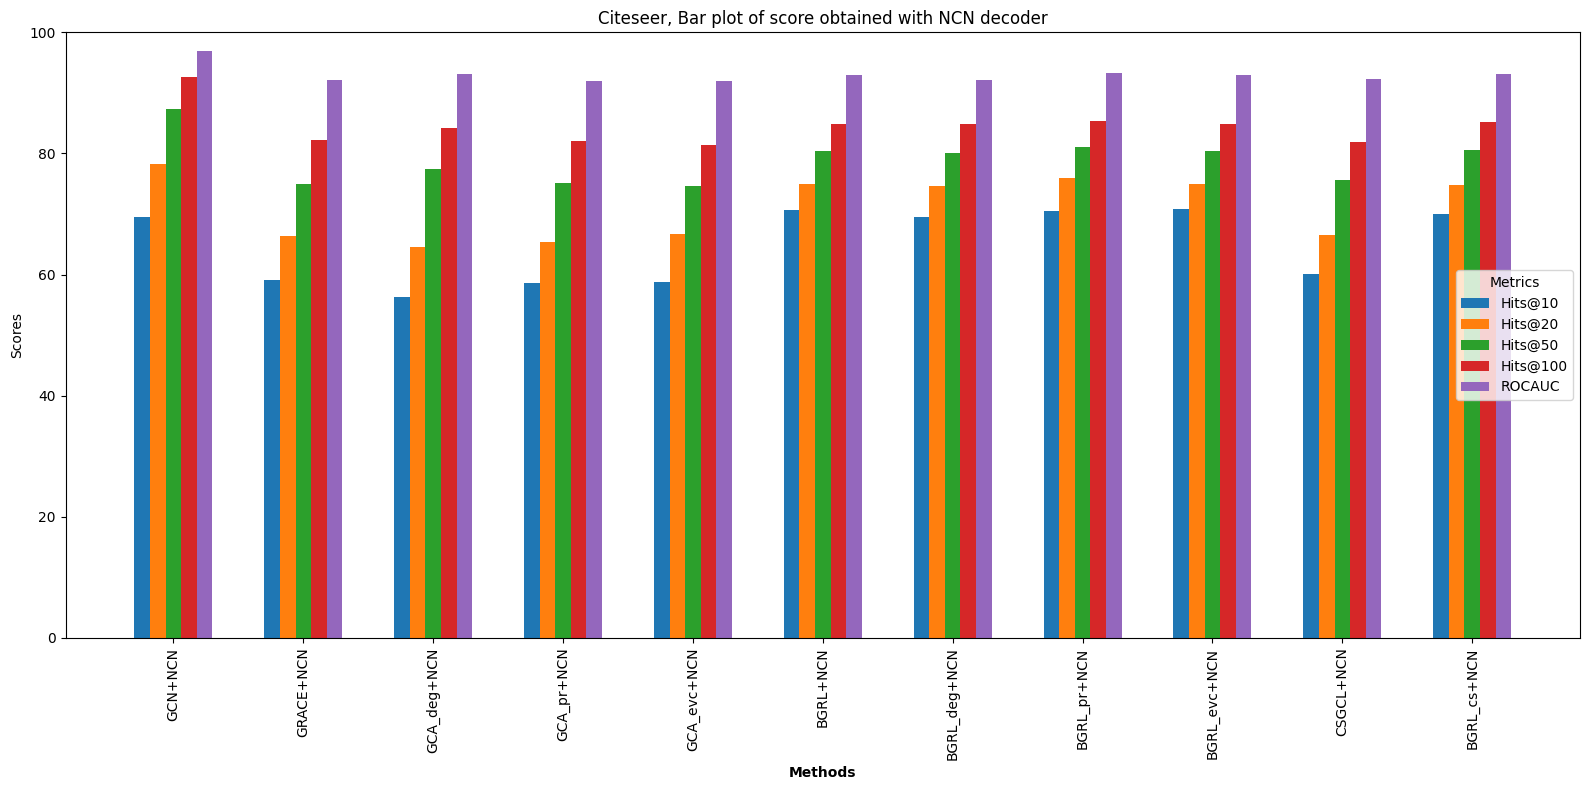

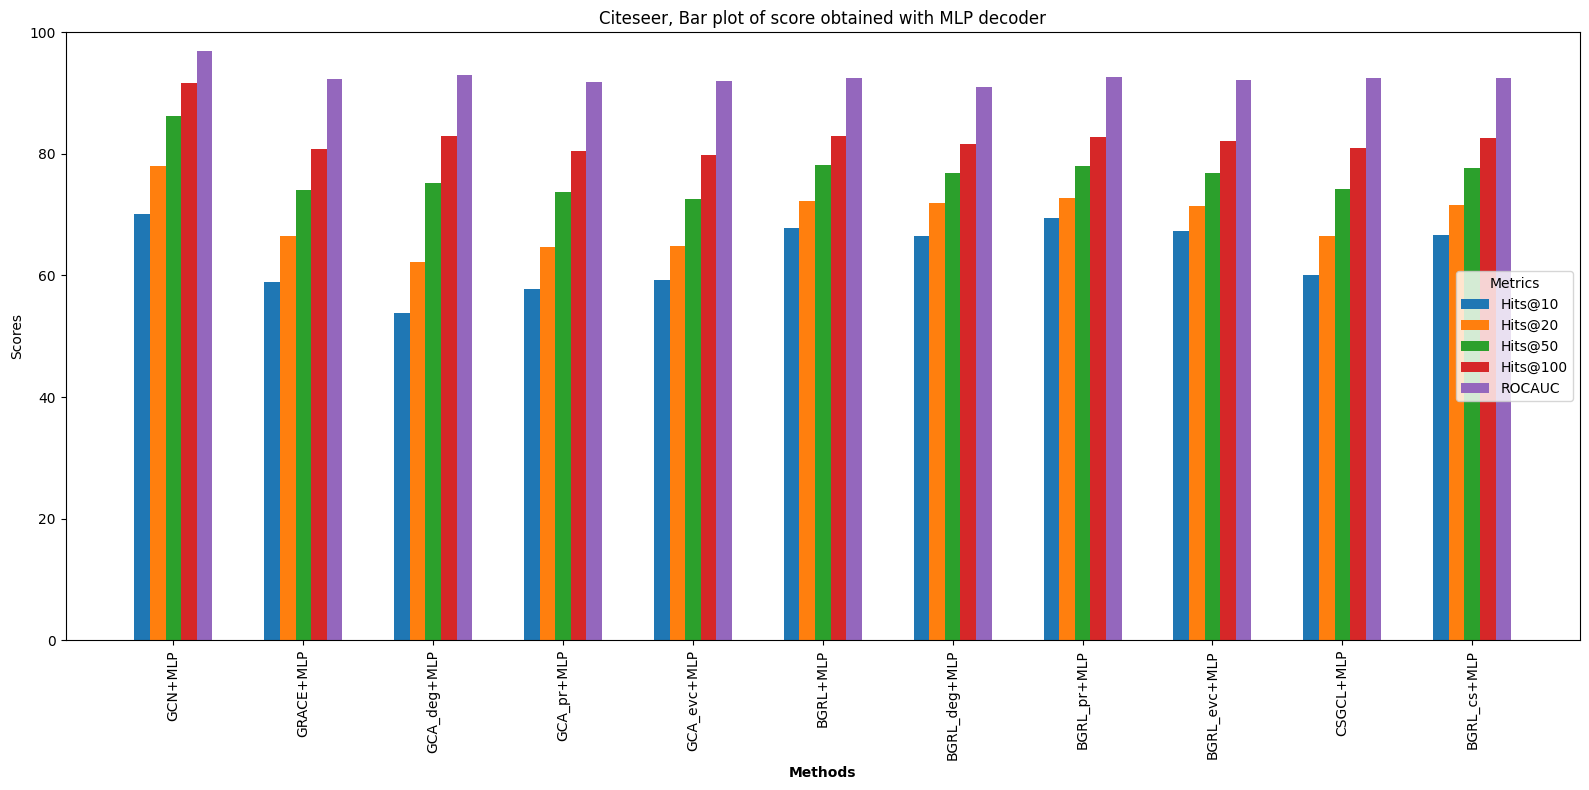

In [4]:
data0_ncn = data0[data0.index.str.contains('NCN')]
data0_mlp = data0[data0.index.str.contains('MLP')]
bar_plot(data0_ncn, "Citeseer, Bar plot of score obtained with NCN decoder")
bar_plot(data0_mlp, "Citeseer, Bar plot of score obtained with MLP decoder")

## Citeseer Only Features

In [5]:
data1 = pd.read_csv('./Citeseer-feature_res.csv', sep=';').T
data1.columns = data1.loc['metrics']
data1.drop(index='metrics', inplace=True)
data1.index = data1.index.str.replace('Citeseer ', '', regex=False)
print('Citeseer-feature')
print(data1.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
data1

Citeseer-feature
\begin{tabular}{lllll}
\toprule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
66.18$\pm$5.57 & 74.95$\pm$3.42 & 86.42$\pm$1.66 & 91.49$\pm$0.99 & 96.58$\pm$0.45 \\
64.14$\pm$6.47 & 72.75$\pm$3.89 & 83.71$\pm$1.08 & 90.67$\pm$1.08 & 96.5$\pm$0.4 \\
37.92$\pm$3.79 & 47.37$\pm$2.93 & 60.27$\pm$2.62 & 72.55$\pm$2.43 & 89.67$\pm$0.71 \\
35.78$\pm$4.72 & 43.45$\pm$3.55 & 57.07$\pm$3.15 & 68.27$\pm$2.07 & 88.32$\pm$0.95 \\
34.52$\pm$6.53 & 44.56$\pm$5.03 & 59.49$\pm$2.66 & 72.29$\pm$2.72 & 89.61$\pm$0.91 \\
30.66$\pm$3.78 & 40.71$\pm$3.52 & 54.99$\pm$2.34 & 67.57$\pm$2.04 & 88.09$\pm$1.03 \\
34.52$\pm$6.53 & 44.56$\pm$5.03 & 59.49$\pm$2.66 & 72.29$\pm$2.72 & 89.61$\pm$0.91 \\
30.66$\pm$3.78 & 40.71$\pm$3.52 & 54.99$\pm$2.34 & 67.57$\pm$2.04 & 88.09$\pm$1.03 \\
34.52$\pm$6.53 & 44.56$\pm$5.03 & 59.49$\pm$2.66 & 72.29$\pm$2.72 & 89.61$\pm$0.91 \\
30.66$\pm$3.78 & 40.71$\pm$3.52 & 54.99$\pm$2.34 & 67.57$\pm$2.04 & 88.09$\pm$1.03 \\
46.19$\pm$3.55 & 52.02$\pm$4.28 &

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,66.18$\pm$5.57,74.95$\pm$3.42,86.42$\pm$1.66,91.49$\pm$0.99,96.58$\pm$0.45
GCN+MLP,64.14$\pm$6.47,72.75$\pm$3.89,83.71$\pm$1.08,90.67$\pm$1.08,96.5$\pm$0.4
GRACE+NCN,37.92$\pm$3.79,47.37$\pm$2.93,60.27$\pm$2.62,72.55$\pm$2.43,89.67$\pm$0.71
GRACE+MLP,35.78$\pm$4.72,43.45$\pm$3.55,57.07$\pm$3.15,68.27$\pm$2.07,88.32$\pm$0.95
GCA_deg+NCN,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91
GCA_deg+MLP,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03
GCA_pr+NCN,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91
GCA_pr+MLP,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03
GCA_evc+NCN,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91
GCA_evc+MLP,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03


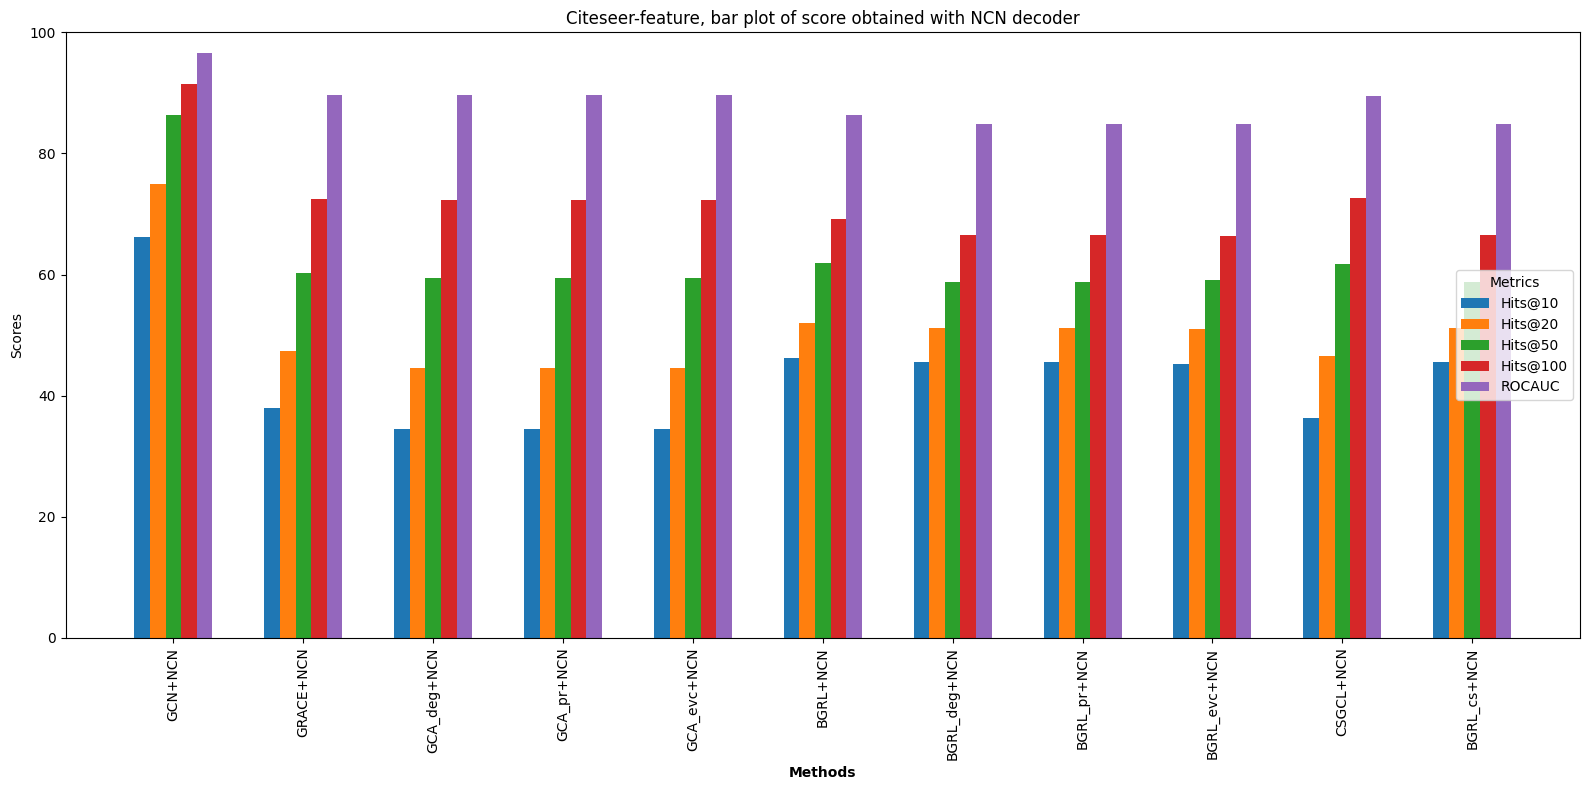

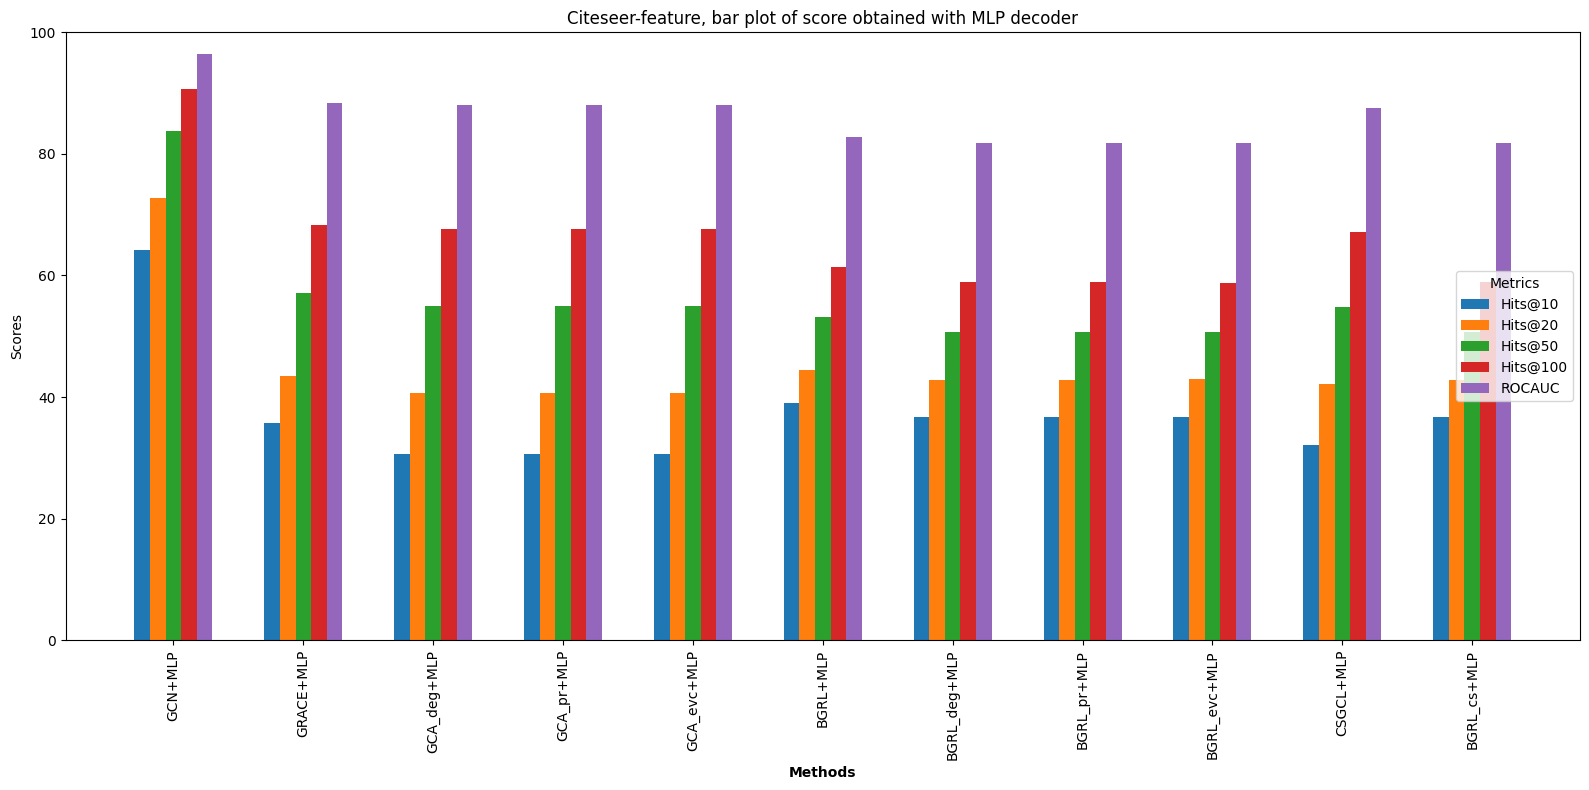

In [6]:
data1_ncn = data1[data1.index.str.contains('NCN')]
data1_mlp = data1[data1.index.str.contains('MLP')]
bar_plot(data1_ncn, "Citeseer-feature, bar plot of score obtained with NCN decoder")
bar_plot(data1_mlp, "Citeseer-feature, bar plot of score obtained with MLP decoder")

## Citeseer Only Structure

In [7]:
data2 = pd.read_csv('./Citeseer-structure_res.csv', sep=';').T
data2.columns = data2.loc['metrics']
data2.drop(index='metrics', inplace=True)
data2.index = data2.index.str.replace('Citeseer ', '', regex=False)
print('Citeseer-structure')
print(data2.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
data2

Citeseer-structure
\begin{tabular}{llllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
GCN+NCN & 31.38$\pm$1.32 & 33.66$\pm$1.09 & 39.26$\pm$1.03 & 44.65$\pm$1.05 & 72.44$\pm$0.96 \\
GCN+MLP & 9.05$\pm$1.72 & 12.47$\pm$1.13 & 20.23$\pm$1.22 & 27.78$\pm$1.17 & 62.53$\pm$1.22 \\
GRACE+NCN & 32.18$\pm$1.78 & 34.92$\pm$1.55 & 39.75$\pm$1.24 & 45.12$\pm$1.73 & 72.78$\pm$1.42 \\
GRACE+MLP & 10.99$\pm$1.49 & 15.27$\pm$1.39 & 22.66$\pm$1.21 & 30.78$\pm$1.85 & 65.27$\pm$1.4 \\
GCA_deg+NCN & 32.31$\pm$1.41 & 35.02$\pm$1.07 & 40.33$\pm$0.7 & 45.74$\pm$1.3 & 73.14$\pm$0.95 \\
GCA_deg+MLP & 9.95$\pm$3.82 & 13.31$\pm$4.77 & 20.0$\pm$6.78 & 27.51$\pm$9.41 & 63.28$\pm$4.65 \\
GCA_pr+NCN & 32.12$\pm$1.64 & 34.48$\pm$0.92 & 39.97$\pm$1.01 & 45.56$\pm$1.59 & 72.88$\pm$0.96 \\
GCA_pr+MLP & 8.26$\pm$4.33 & 11.69$\pm$5.89 & 17.93$\pm$9.01 & 24.31$\pm$12.27 & 61.79$\pm$5.98 \\
GCA_evc+NCN & 31.05$\pm$1.37 & 34.04$\pm$1.43 & 39.21$\pm$1.31 & 44.43$\pm$1.37 & 72.23$\pm$0.82 \

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,31.38$\pm$1.32,33.66$\pm$1.09,39.26$\pm$1.03,44.65$\pm$1.05,72.44$\pm$0.96
GCN+MLP,9.05$\pm$1.72,12.47$\pm$1.13,20.23$\pm$1.22,27.78$\pm$1.17,62.53$\pm$1.22
GRACE+NCN,32.18$\pm$1.78,34.92$\pm$1.55,39.75$\pm$1.24,45.12$\pm$1.73,72.78$\pm$1.42
GRACE+MLP,10.99$\pm$1.49,15.27$\pm$1.39,22.66$\pm$1.21,30.78$\pm$1.85,65.27$\pm$1.4
GCA_deg+NCN,32.31$\pm$1.41,35.02$\pm$1.07,40.33$\pm$0.7,45.74$\pm$1.3,73.14$\pm$0.95
GCA_deg+MLP,9.95$\pm$3.82,13.31$\pm$4.77,20.0$\pm$6.78,27.51$\pm$9.41,63.28$\pm$4.65
GCA_pr+NCN,32.12$\pm$1.64,34.48$\pm$0.92,39.97$\pm$1.01,45.56$\pm$1.59,72.88$\pm$0.96
GCA_pr+MLP,8.26$\pm$4.33,11.69$\pm$5.89,17.93$\pm$9.01,24.31$\pm$12.27,61.79$\pm$5.98
GCA_evc+NCN,31.05$\pm$1.37,34.04$\pm$1.43,39.21$\pm$1.31,44.43$\pm$1.37,72.23$\pm$0.82
GCA_evc+MLP,8.34$\pm$4.42,11.13$\pm$5.81,17.44$\pm$8.76,24.08$\pm$12.07,61.51$\pm$5.82


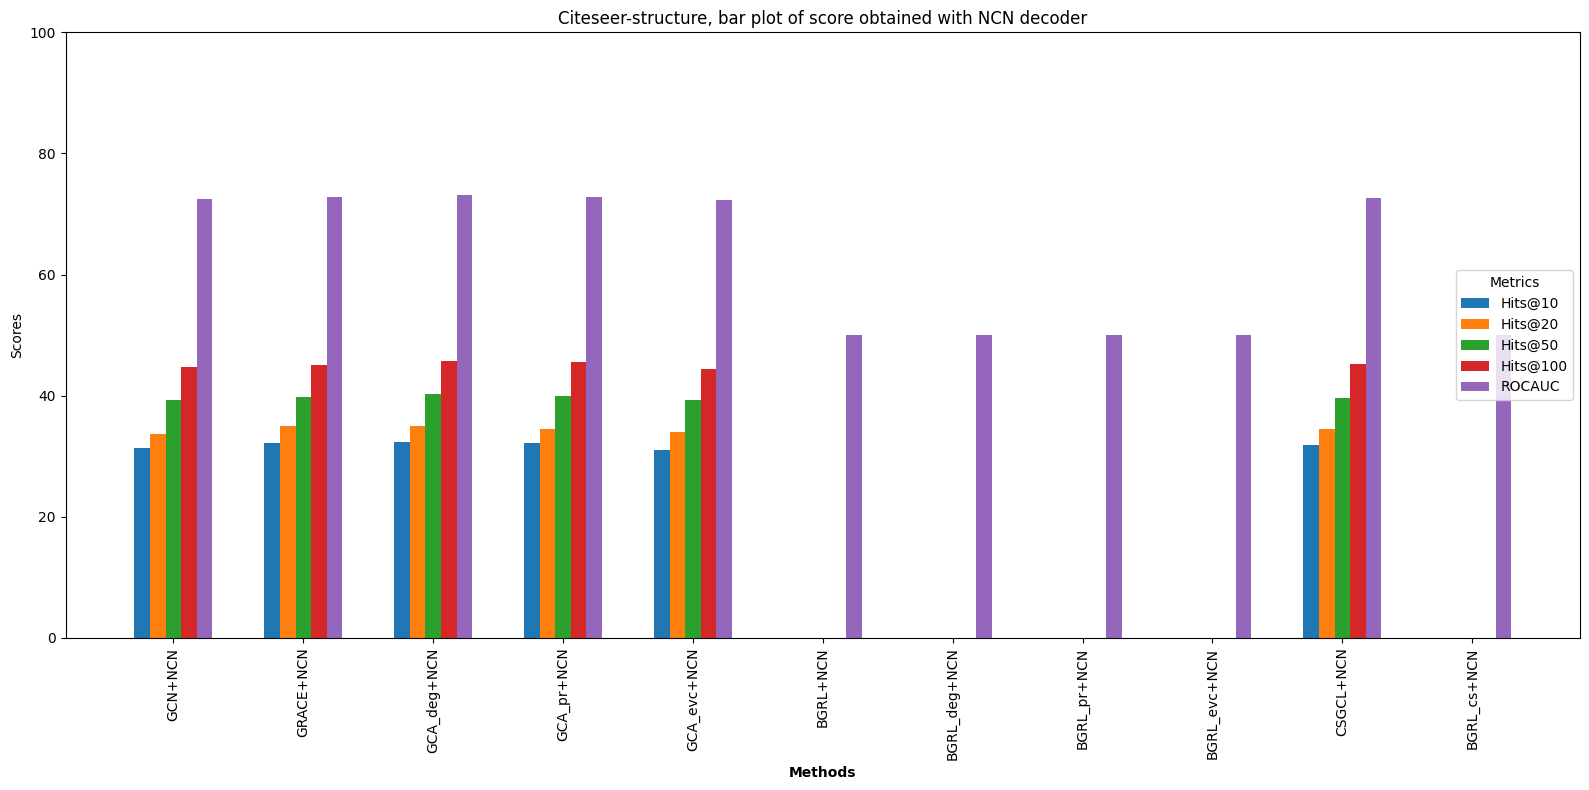

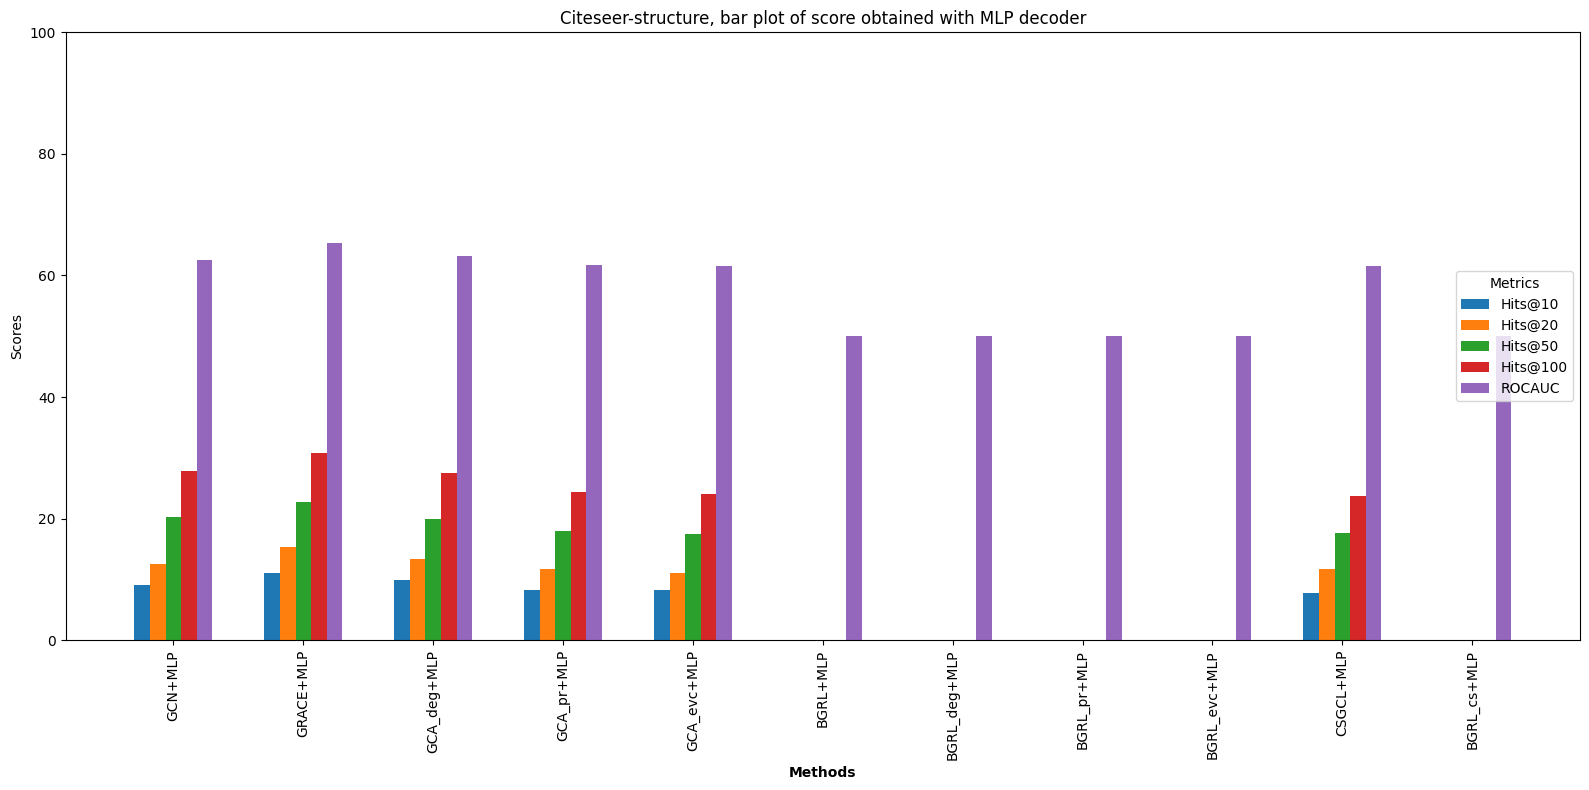

In [8]:
data2_ncn = data2[data2.index.str.contains('NCN')]
data2_mlp = data2[data2.index.str.contains('MLP')]
bar_plot(data2_ncn, "Citeseer-structure, bar plot of score obtained with NCN decoder")
bar_plot(data2_mlp, "Citeseer-structure, bar plot of score obtained with MLP decoder")

In [9]:
citeseer = pd.concat([data0, data1, data2], axis=1)
print('citeseer final')
print(citeseer.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
citeseer

citeseer final
\begin{tabular}{llllllllllllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
GCN+NCN & 69.45$\pm$4.93 & 78.29$\pm$3.76 & 87.3$\pm$1.82 & 92.58$\pm$0.97 & 96.94$\pm$0.38 & 66.18$\pm$5.57 & 74.95$\pm$3.42 & 86.42$\pm$1.66 & 91.49$\pm$0.99 & 96.58$\pm$0.45 & 31.38$\pm$1.32 & 33.66$\pm$1.09 & 39.26$\pm$1.03 & 44.65$\pm$1.05 & 72.44$\pm$0.96 \\
GCN+MLP & 70.07$\pm$4.62 & 78.02$\pm$2.69 & 86.21$\pm$1.05 & 91.67$\pm$0.71 & 96.93$\pm$0.35 & 64.14$\pm$6.47 & 72.75$\pm$3.89 & 83.71$\pm$1.08 & 90.67$\pm$1.08 & 96.5$\pm$0.4 & 9.05$\pm$1.72 & 12.47$\pm$1.13 & 20.23$\pm$1.22 & 27.78$\pm$1.17 & 62.53$\pm$1.22 \\
GRACE+NCN & 59.05$\pm$2.76 & 66.42$\pm$1.75 & 75.03$\pm$1.86 & 82.24$\pm$1.89 & 92.21$\pm$0.91 & 37.92$\pm$3.79 & 47.37$\pm$2.93 & 60.27$\pm$2.62 & 72.55$\pm$2.43 & 89.67$\pm$0.71 & 32.18$\pm$1.78 & 34.92$\pm$1.55 & 39.75$\pm$1.24 & 45.12$\pm$1

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,69.45$\pm$4.93,78.29$\pm$3.76,87.3$\pm$1.82,92.58$\pm$0.97,96.94$\pm$0.38,66.18$\pm$5.57,74.95$\pm$3.42,86.42$\pm$1.66,91.49$\pm$0.99,96.58$\pm$0.45,31.38$\pm$1.32,33.66$\pm$1.09,39.26$\pm$1.03,44.65$\pm$1.05,72.44$\pm$0.96
GCN+MLP,70.07$\pm$4.62,78.02$\pm$2.69,86.21$\pm$1.05,91.67$\pm$0.71,96.93$\pm$0.35,64.14$\pm$6.47,72.75$\pm$3.89,83.71$\pm$1.08,90.67$\pm$1.08,96.5$\pm$0.4,9.05$\pm$1.72,12.47$\pm$1.13,20.23$\pm$1.22,27.78$\pm$1.17,62.53$\pm$1.22
GRACE+NCN,59.05$\pm$2.76,66.42$\pm$1.75,75.03$\pm$1.86,82.24$\pm$1.89,92.21$\pm$0.91,37.92$\pm$3.79,47.37$\pm$2.93,60.27$\pm$2.62,72.55$\pm$2.43,89.67$\pm$0.71,32.18$\pm$1.78,34.92$\pm$1.55,39.75$\pm$1.24,45.12$\pm$1.73,72.78$\pm$1.42
GRACE+MLP,59.0$\pm$3.93,66.45$\pm$2.23,74.02$\pm$1.53,80.89$\pm$0.93,92.32$\pm$0.52,35.78$\pm$4.72,43.45$\pm$3.55,57.07$\pm$3.15,68.27$\pm$2.07,88.32$\pm$0.95,10.99$\pm$1.49,15.27$\pm$1.39,22.66$\pm$1.21,30.78$\pm$1.85,65.27$\pm$1.4
GCA_deg+NCN,56.21$\pm$6.0,64.51$\pm$5.01,77.44$\pm$3.17,84.22$\pm$3.55,93.1$\pm$1.29,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91,32.31$\pm$1.41,35.02$\pm$1.07,40.33$\pm$0.7,45.74$\pm$1.3,73.14$\pm$0.95
GCA_deg+MLP,53.75$\pm$8.25,62.29$\pm$5.22,75.25$\pm$4.27,82.89$\pm$3.76,92.91$\pm$1.2,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03,9.95$\pm$3.82,13.31$\pm$4.77,20.0$\pm$6.78,27.51$\pm$9.41,63.28$\pm$4.65
GCA_pr+NCN,58.54$\pm$3.07,65.35$\pm$2.64,75.14$\pm$2.17,82.05$\pm$1.59,92.04$\pm$0.69,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91,32.12$\pm$1.64,34.48$\pm$0.92,39.97$\pm$1.01,45.56$\pm$1.59,72.88$\pm$0.96
GCA_pr+MLP,57.71$\pm$2.88,64.69$\pm$2.21,73.73$\pm$1.37,80.55$\pm$1.2,91.87$\pm$0.63,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03,8.26$\pm$4.33,11.69$\pm$5.89,17.93$\pm$9.01,24.31$\pm$12.27,61.79$\pm$5.98
GCA_evc+NCN,58.82$\pm$2.42,66.64$\pm$2.01,74.62$\pm$1.94,81.32$\pm$1.14,91.91$\pm$0.61,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91,31.05$\pm$1.37,34.04$\pm$1.43,39.21$\pm$1.31,44.43$\pm$1.37,72.23$\pm$0.82
GCA_evc+MLP,59.32$\pm$2.39,64.84$\pm$1.98,72.66$\pm$1.27,79.88$\pm$1.32,91.92$\pm$0.71,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03,8.34$\pm$4.42,11.13$\pm$5.81,17.44$\pm$8.76,24.08$\pm$12.07,61.51$\pm$5.82


## Pubmed

In [10]:
data3 = pd.read_csv('./Pubmed_res.csv', sep=';').T
print('Pubmed')
print(data3.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
data3

Pubmed
\begin{tabular}{llllll}
\toprule
0 & 1 & 2 & 3 & 4 & 5 \\
\midrule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & nan$\pm$nan \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & nan$\pm$nan \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 716.99$\pm$117.88 \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 418.25$\pm$0.19 \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 28.8$\pm$0.23 \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 28.9$\pm$0.18 \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 28.86$\pm$0.19 \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 29.05$\pm$0.28 \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 29.03$\pm$0.32 \\
100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 100$\pm$100 & 2

,0,1,2,3,4,5
metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,pretrain_time
Pubmed GCN+NCN,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,nan$\pm$nan
Pubmed GCN+MLP,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,nan$\pm$nan
Pubmed GRACE+NCN,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,716.99$\pm$117.88
Pubmed GRACE+MLP,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,418.25$\pm$0.19
Pubmed BGRL+NCN,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,28.8$\pm$0.23
Pubmed BGRL+MLP,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,28.9$\pm$0.18
Pubmed BGRL_deg+NCN,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,28.86$\pm$0.19
Pubmed BGRL_deg+MLP,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,29.05$\pm$0.28
Pubmed BGRL_pr+NCN,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,100$\pm$100,29.03$\pm$0.32
